실험02. 교류회로의 전력



Vin[V] 실험에 사용한 600Hz sin wave 전압원 전압값을 입력(ex: 5Vrms 경우 5를 입력):      5
600Hz 입력전압일 때 1kohm 저항에 걸리는 rms 전압값(오실로스코프에서 실효치) 측정한 값을 입력(ex: 4.96V인 경우 4.96을 입력):     4.96
Vin 전압을 재측정하여 rms 전압값(실효치)을 입력(ex: 5V인 경우 5를 입력):     5



        [표 2-1]
 VR           | Vin           |  I[mA]         |  피상전력 S=V*A    |  유효전력 P=VR제곱/R
--------------------------------------------------------------------------------------------------
 4.96         | 5.0           |  4.96          |  24.8             |      24.602      

        [표 2-2]
      역률      | 위상각 theta     |  위상각 theta     |  위상각의         
 (Power Factor) | (계산값)         |  (측정값)         |  상대오차         
--------------------------------------------------------------------------------------------------------------
  0.992        |   7.092         |    7.252         |    -0.16        


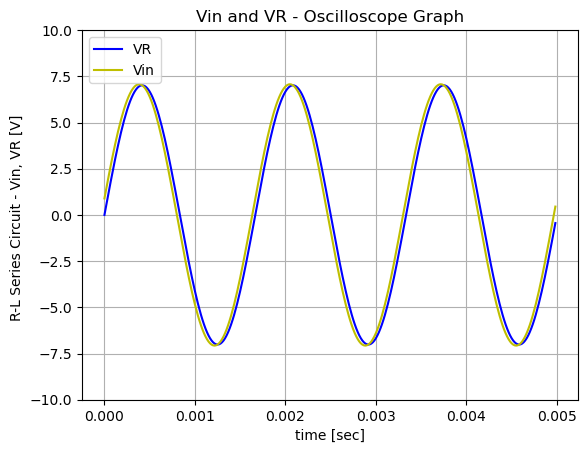

Vin이 VR 보다 radian  0.127 즉, 각도로는 7.252 º 앞선다


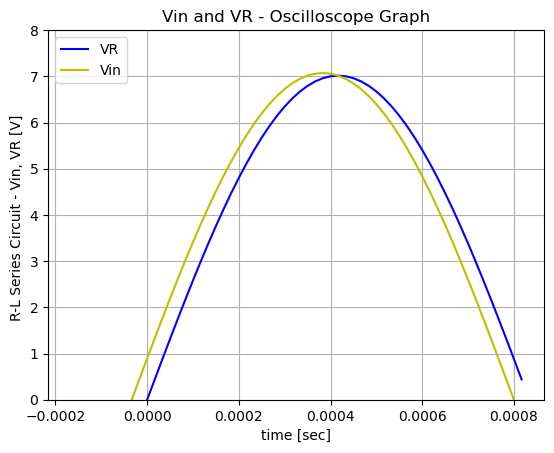

In [5]:
# 실험 제목 출력 
print("실험02. 교류전력-역률분석")
print()

# 실험에 사용한 회로 정수를 입력함
import numpy as np
import math


f=60     # 주파수 입력 

Vin_set=input("Vin[V] 실험에 사용한 60Hz sin wave 전압원 rms 전압값을 입력(ex: 10Vrms 경우 10을 입력):     ")  # 1차측 sin wave 전압원 전압값을 입력하세요.
Vin_set=float(Vin_set)   #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.

n=2        # 1차와 2차 턴수비 (여기서는 1:2 이므로 2)
RL=1e3     # 부하저항으로 실험에 사용한 R값   1k[ohm]

# 실험결과 측정치를 입력함
=input("600Hz 입력전압일 때 1kohm 저항에 걸리는 rms 전압값(오실로스코프에서 실효치) 측정한 값을 입력(ex: 4.96V인 경우 4.96을 입력):    ")     # 측정해서 입력하세요.
VR=float(VR)    #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.
Vin=input("Vin 전압을 재측정하여 rms 전압값(실효치)을 입력(ex: 5V인 경우 5를 입력):    ")    # 측정해서 입력하세요.
Vin=float(Vin)  #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.
I=VR           #1kohm에 걸리는 전압이므로 I=V/R에서 1kohm에 흐르는 전류치[mA]와 수치가 동일
WA=Vin*I       # 피상전력을 계산.   입력전압(rms)*입력전류(rms)
WT=VR**2/R*1000     # R에만 소모되는 전력이 유효전력(True Power)이므로 VR제곱/R으로 계산함.  [mW]단위로 표시하기 위해 *1000 

PF=WT/WA     # 역률(Power Factor)의 정의로 부터 Power Factor를 계산

XL=2*np.pi*f*33e-3        # 위상각(theta)를 계산하기 위해 XL을 먼저 계산
theta=np.arctan(XL/R)     # phasor diagram에서 위상차 tan 각도를 계산
theta_deg_cal=round(theta*180/np.pi,3)    # radian 각도값을 60분법 각도로 변경하고 소수점 3째자리까지 표시함

# 위상각 theta의 측정값 도출  - VR 측정값과 Vin 측정값에서 cos관계인 점을 이용해서 theta를 도출
theta_measure=np.arccos(VR/Vin)
theta_deg_measure=round(theta_measure*180/np.pi,3)

print()
print("        [표 2-1]")
# 데이터 헤더 및 데이터 출력
print(" {:<12} | {:<12}  |  {:<12}  |  {:<12}  |  {:<12}".format("VR","Vin","I[mA]","피상전력 S=V*A","유효전력 P=VR제곱/R"))
print("--------------------------------------------------------------------------------------------------")
print(" {:<12} | {:<12}  |  {:<12}  |  {:<12}     |      {:<12}".format(VR,  Vin  , I  ,   WA,   round(WT,3)))
print


print()
print("        [표 2-2]")
# 데이터 헤더 및 데이터 출력
print(" {:<12} | {:<12}  |  {:<12}  |  {:<12} ".format(    "     역률",      "위상각 theta",  "위상각 theta",     "위상각의" ))
print(" {:<12} | {:<12}  |  {:<12}  |  {:<12} ".format("(Power Factor)",    "(계산값)",   "(측정값)",         "상대오차" ))
print("--------------------------------------------------------------------------------------------------------------")
# 데이터 출력
print("  {:<12} |   {:<12}  |    {:<12}  |    {:<12} ".format(PF,    theta_deg_cal,     theta_deg_measure,  round(theta_deg_cal-theta_deg_measure,3)))   



# 오실로스코프 화면 파형 그리기
import numpy as np
import matplotlib.pyplot as plt


f=600
fs=f*100;   dt=1/fs;  N=300   #샘플링주파수=표시주파수*100Hz, 300개 샘플이면 3주기 표시함 
t=np.arange(0,N)*dt           # 시간축은 1주기*300샘플
y1t=(math.sqrt(2))*VR*np.sin(2*np.pi*f*t)   # 크기 √￣2*VR, 주파수 600Hz 정현파
y2t=(math.sqrt(2))*Vin*np.sin(2*np.pi*f*t+theta_measure) # 크기는 Vin 위상은 theta_measure 앞선 정현파
plt.xlabel("time [sec]")
plt.ylabel("R-L Series Circuit - Vin, VR [V] ")
plt.title("Vin and VR - Oscilloscope Graph")
plt.plot(t, y1t,"b", label="VR")
plt.plot(t, y2t,"y", label="Vin")
plt.legend(loc="upper left")
plt.ylim(-10,10)
plt.grid()
plt.show()
print("Vin이 VR 보다 radian ", round(theta_measure,3), "즉, 각도로는", theta_deg_measure, "º 앞선다")


# 오실로스코프 화면 파형 확대해서 그리기
f=600
fs=f*100;   dt=1/fs;  N=50   #샘플링주파수=표시주파수*100 Hz, 100개 샘플이면 1주기만 표시함
t=np.arange(-10,N)*dt           # 시간축은 1주기*100샘플
y1t=(math.sqrt(2))*VR*np.sin(2*np.pi*f*t)   # 크기 √￣2*VR, 주파수 600Hz 정현파
y2t=(math.sqrt(2))*Vin*np.sin(2*np.pi*f*t+theta_measure) # 크기는 크기 √￣2*Vin, 위상은 theta_measure 앞선 정현파
plt.xlabel("time [sec]")
plt.ylabel("R-L Series Circuit - Vin, VR [V] ")
plt.title("Vin and VR - Oscilloscope Graph")
plt.plot(t, y1t,"b", label="VR")
plt.plot(t, y2t,"y", label="Vin")
plt.legend(loc="upper left")
plt.ylim(0,8)
plt.grid()
plt.show()
